#Instalar dependencias y generar rutas

In [ ]:
!apt-get install -y fluidsynth
!pip install -q music21 pretty_midi midi2audio


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
import os
import json
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


In [ ]:
BASE_DIR = Path("/content/melody_project")
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Carpetas listas:")
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

!ls -R /content/melody_project


Carpetas listas:
DATA_DIR: /content/melody_project/data
MODELS_DIR: /content/melody_project/models
/content/melody_project:
data  models

/content/melody_project/data:
detallado_castlevania_notas.npy
detallado_castlevania_notas_unicas.json
detallado_castlevania_secuencias_datos.npz
notas_castlevania_notas.npy
notas_castlevania_notas_unicas.json
notas_castlevania_secuencias_datos.npz
notas_melody_castlevania_notas.npy
notas_melody_castlevania_notas_unicas.json
notas_melody_castlevania_secuencias_datos.npz
notas_multitrack_castlevania_notas.npy
notas_multitrack_castlevania_notas_unicas.json
notas_multitrack_castlevania_secuencias_datos.npz

/content/melody_project/models:
model_notas_castlevania_embed.keras


In [ ]:
def load_sequence_data(data_path, prefix):
    with open(data_path / f"{prefix}_notas_unicas.json", "r") as f:
        unique_notes = json.load(f)

    data = np.load(data_path / f"{prefix}_secuencias_datos.npz")
    inputs, targets = data["inputs"], data["targets"]

    n_vocab = len(unique_notes)
    inputs = np.reshape(inputs, (inputs.shape[0], inputs.shape[1], 1)) / float(n_vocab)
    targets = to_categorical(targets, num_classes=n_vocab)

    return inputs, targets, n_vocab


#Crear LSTM con embedding

In [ ]:
def build_lstm_model_embed(n_vocab, seq_length=50):
    model = Sequential([
        Embedding(input_dim=n_vocab, output_dim=128, input_length=seq_length),
        LSTM(256, return_sequences=True),
        Dropout(0.3),
        LSTM(256),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(n_vocab, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(0.001),
        metrics=['accuracy']
    )
    return model


# Función para Entrenar modelo

In [ ]:
def train_dataset_embed(prefix, epochs=50):
    print(f"\n--- Entrenando modelo con Embedding: {prefix.upper()} ---")

    with open(DATA_DIR / f"{prefix}_notas_unicas.json", "r") as f:
        unique_notes = json.load(f)
    data = np.load(DATA_DIR / f"{prefix}_secuencias_datos.npz")
    inputs, targets = data["inputs"], data["targets"]

    n_vocab = len(unique_notes)
    inputs = np.reshape(inputs, (inputs.shape[0], inputs.shape[1]))
    targets = to_categorical(targets, num_classes=n_vocab)

    model = build_lstm_model_embed(n_vocab)
    checkpoint_path = MODELS_DIR / f"model_{prefix}_embed.keras"

    checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='loss', save_best_only=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-5)

    history = model.fit(
        inputs, targets,
        epochs=epochs,
        batch_size=64,
        validation_split=0.1,
        callbacks=[checkpoint, reduce_lr],
        verbose=1
    )

    print(f"Modelo {prefix} guardado en {checkpoint_path}")
    return model, history


##Función para reanudar entrenamiento

In [ ]:
def continue_training_embed(prefix, extra_epochs=40):
    print(f"\n--- Reanudando entrenamiento (Embedding): {prefix.upper()} ---")

    model_path = MODELS_DIR / f"model_{prefix}_embed.keras"
    model = load_model(model_path)

    with open(DATA_DIR / f"{prefix}_notas_unicas.json", "r") as f:
        unique_notes = json.load(f)
    data = np.load(DATA_DIR / f"{prefix}_secuencias_datos.npz")
    inputs, targets = data["inputs"], data["targets"]

    n_vocab = len(unique_notes)
    inputs = np.reshape(inputs, (inputs.shape[0], inputs.shape[1]))
    targets = to_categorical(targets, num_classes=n_vocab)

    checkpoint = ModelCheckpoint(filepath=model_path, monitor='loss', save_best_only=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-5)

    history = model.fit(
        inputs, targets,
        epochs=extra_epochs,
        batch_size=64,
        validation_split=0.1,
        callbacks=[checkpoint, reduce_lr],
        verbose=1
    )

    return history


#Entrenar

In [ ]:
#model, history = train_dataset_embed("notas_castlevania", epochs=5)

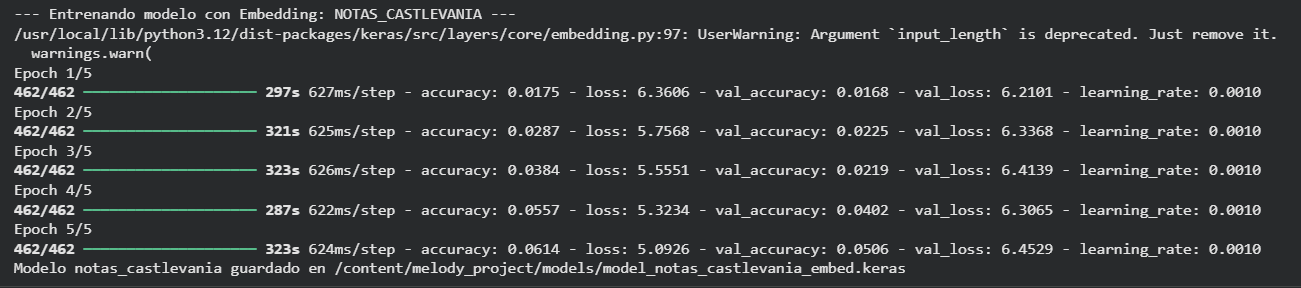

##Continuar entrenando

In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 289s 614ms/step - accuracy: 0.8456 - loss: 0.4900 - val_accuracy: 0.1148 - val_loss: 15.3032 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 277s 599ms/step - accuracy: 0.8472 - loss: 0.4871 - val_accuracy: 0.1127 - val_loss: 15.3718 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 276s 597ms/step - accuracy: 0.8441 - loss: 0.4919 - val_accuracy: 0.1133 - val_loss: 15.1753 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 323s 598ms/step - accuracy: 0.8476 - loss: 0.4778 - val_accuracy: 0.1148 - val_loss: 15.3438 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 275s 595ms/step - accuracy: 0.8492 - loss: 0.4814 - val_accuracy: 0.1142 - val_loss: 15.6485 - learning_rate: 0.0010


In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 281s 599ms/step - accuracy: 0.8450 - loss: 0.4852 - val_accuracy: 0.1170 - val_loss: 15.5673 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 277s 599ms/step - accuracy: 0.8554 - loss: 0.4640 - val_accuracy: 0.1224 - val_loss: 15.2317 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 280s 606ms/step - accuracy: 0.8584 - loss: 0.4538 - val_accuracy: 0.1203 - val_loss: 15.4925 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 282s 610ms/step - accuracy: 0.8547 - loss: 0.4558 - val_accuracy: 0.1182 - val_loss: 15.6157 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 325s 616ms/step - accuracy: 0.8539 - loss: 0.4813 - val_accuracy: 0.1194 - val_loss: 15.5521 - learning_rate: 0.0010


In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 286s 609ms/step - accuracy: 0.8623 - loss: 0.4345 - val_accuracy: 0.1170 - val_loss: 16.0903 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 282s 611ms/step - accuracy: 0.8598 - loss: 0.4328 - val_accuracy: 0.1185 - val_loss: 15.9972 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 282s 611ms/step - accuracy: 0.8621 - loss: 0.4302 - val_accuracy: 0.1176 - val_loss: 15.7518 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 282s 611ms/step - accuracy: 0.8672 - loss: 0.4184 - val_accuracy: 0.1188 - val_loss: 15.3851 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 286s 620ms/step - accuracy: 0.8678 - loss: 0.4224 - val_accuracy: 0.1142 - val_loss: 16.1828 - learning_rate: 0.0010


In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 288s 614ms/step - accuracy: 0.8715 - loss: 0.4116 - val_accuracy: 0.1145 - val_loss: 16.0358 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 283s 612ms/step - accuracy: 0.8702 - loss: 0.3983 - val_accuracy: 0.1200 - val_loss: 15.8741 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 282s 610ms/step - accuracy: 0.8707 - loss: 0.3978 - val_accuracy: 0.1221 - val_loss: 16.5082 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 285s 617ms/step - accuracy: 0.8704 - loss: 0.4036 - val_accuracy: 0.1154 - val_loss: 16.0707 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 318s 609ms/step - accuracy: 0.8755 - loss: 0.3928 - val_accuracy: 0.1203 - val_loss: 16.1805 - learning_rate: 0.0010


In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 290s 617ms/step - accuracy: 0.8724 - loss: 0.4023 - val_accuracy: 0.1173 - val_loss: 16.3279 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 321s 614ms/step - accuracy: 0.8795 - loss: 0.3843 - val_accuracy: 0.1206 - val_loss: 16.3288 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 288s 624ms/step - accuracy: 0.8765 - loss: 0.3822 - val_accuracy: 0.1157 - val_loss: 16.2256 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 290s 627ms/step - accuracy: 0.8796 - loss: 0.3692 - val_accuracy: 0.1130 - val_loss: 16.5908 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 319s 622ms/step - accuracy: 0.8752 - loss: 0.3828 - val_accuracy: 0.1221 - val_loss: 16.6239 - learning_rate: 0.0010


In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 292s 623ms/step - accuracy: 0.8804 - loss: 0.3693 - val_accuracy: 0.1142 - val_loss: 17.3373 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 285s 618ms/step - accuracy: 0.8787 - loss: 0.3777 - val_accuracy: 0.1206 - val_loss: 16.3471 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 287s 621ms/step - accuracy: 0.8832 - loss: 0.3639 - val_accuracy: 0.1173 - val_loss: 16.2931 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 285s 617ms/step - accuracy: 0.8850 - loss: 0.3620 - val_accuracy: 0.1200 - val_loss: 16.5511 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 317s 606ms/step - accuracy: 0.8856 - loss: 0.3529 - val_accuracy: 0.1161 - val_loss: 16.4389 - learning_rate: 0.0010


In [ ]:
continue_training_embed("notas_castlevania", extra_epochs=5)


--- Reanudando entrenamiento (Embedding): NOTAS_CASTLEVANIA ---
Epoch 1/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 287s 614ms/step - accuracy: 0.8886 - loss: 0.3513 - val_accuracy: 0.1194 - val_loss: 16.8966 - learning_rate: 0.0010
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 286s 618ms/step - accuracy: 0.8849 - loss: 0.3610 - val_accuracy: 0.1206 - val_loss: 16.9736 - learning_rate: 0.0010
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 316s 605ms/step - accuracy: 0.8897 - loss: 0.3525 - val_accuracy: 0.1221 - val_loss: 16.5905 - learning_rate: 0.0010
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 282s 610ms/step - accuracy: 0.8919 - loss: 0.3431 - val_accuracy: 0.1157 - val_loss: 16.6706 - learning_rate: 0.0010
Epoch 5/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 326s 620ms/step - accuracy: 0.8881 - loss: 0.3518 - val_accuracy: 0.1185 - val_loss: 17.0646 - learning_rate: 0.0010
